# **Diplomado IA: Audio y Video - Parte 1**. <br> Práctico 37: Frameworks y Datasets de Audio
---
---

**Profesores:**
- Alain Raymond
- Gabriel Sepúlveda

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**
Vicente Zapata

El siguiente práctico cuanta con 3 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

## Parte 1 - Frameworks de Sonido

### Librosa

$\texttt{Librosa}$ (https://librosa.org/) es una librería de Python que nos permite trabajar con archivos de audio, manipularlos y convertirlos eventualmente en archivos $\texttt{numpy}$ que pueden ser fácilmente transformados en tensores de PyTorch.

### Torchaudio

$\texttt{Torchaudio}$ es la librería de Pytorch para manejar audio. Veremos más adelante cómo ocuparla.

Ya vienen preinstaladas en Colab. Para instalarlas, pueden ocupar los siguientes comandos.

> pip install torchaudio

> pip install librosa


Bajemos un par de archivos para hacer pruebas:

In [45]:
!wget https://freewavesamples.com/files/Woman-Laughing.wav -q --show-progress
!wget https://download.samplelib.com/mp3/sample-15s.mp3  -q --show-progress

Woman-Laughing.wav. 100%[===================>] 223.50K  --.-KB/s    in 0.1s    
sample-15s.mp3.1    100%[===================>] 300.25K  1.57MB/s    in 0.2s    


In [46]:
!rm *.mp3

### (OPCIONAL)

Si no les baja el archivo sample-15s.mp3, ejecuten el siguiente código. Si les funciona SÁLTENSE ESTO.

In [47]:
!wget https://filesamples.com/samples/audio/mp3/sample4.mp3 -q --show-progress
!mv sample4.mp3 sample-15s.mp3

sample4.mp3             [ <=>                ]   3.73M  --.-KB/s    in 0.05s   


## Abriendo archivos con $\texttt{librosa}$

In [48]:
import librosa
file1 = "Woman-Laughing.wav"
file2 = "sample-15s.mp3"
sound_file1, sr1 = librosa.load(file1)
print("Largo del archivo: ", sound_file1.shape, "Sampling Rate Detectado:", sr1)

Largo del archivo:  (28587,) Sampling Rate Detectado: 22050


El resultado de ocupar la función $\texttt{load}$ nos entrega dos valores:
* **sound_file1:** es un arreglo $\texttt{numpy}$ con las amplitudes sampleadas digitalmente. Es decir, la representación digital de nuestro archivo de audio.
* **sr1:** el sampling rate que ocupó librosa a la hora de cargar el archivo.

Como tipo de dato $\texttt{numpy}$, podemos hacer todas las cosas que podemos hacer con él: indexar, sumar, multiplicar, restar, etc. Por ejemplo, escuchemos el primer segundo del archivo que cargamos:


In [49]:
import IPython.display as ipd # Librería para escuchar audio en un notebook
ipd.Audio(sound_file1[:sr1], rate=sr1)

Repitamos con otro archivo, pero ahora 3 segundos:

In [50]:
sound_file2, sr2 = librosa.load(file2)
print("Largo del archivo: ", sound_file2.shape, "Sampling Rate Detectado:", sr2)
ipd.Audio(sound_file2[:3*sr2], rate=sr2)

Largo del archivo:  (5390405,) Sampling Rate Detectado: 22050


Al parecer todo anda bien. Revisemos un poco más de información de estos archivos con los que trabajamos, usando la herramienta $\texttt{file}$ de Linux.

In [51]:
!apt-get install file -qq
!file Woman-Laughing.wav
!file sample-15s.mp3

Woman-Laughing.wav: RIFF (little-endian) data, WAVE audio, Microsoft PCM, 16 bit, stereo 44100 Hz
sample-15s.mp3: Audio file with ID3 version 2.4.0, contains: MPEG ADTS, layer III, v1, 64 kbps, 44.1 kHz, Stereo


Esto es extraño, el segundo archivo fue sampleado automáticamente a 22050 Hz, pero cuando leemos su metadata con el comando $\texttt{file}$, vemos que en verdad su *sampling rate* es de 44100Hz. ¿Qué está pasando acá? Lo que pasa, es que la función $\texttt{load}$ toma un segundo parámetro $\texttt{sr}$ que indica a cuanto samplear el archivo a la hora de leerlo. Sin embargo, esta función sí toma en cuenta la metadata del archivo y samplea 22050 veces sobre los 44100 puntos originales, e interpola para conseguir los valores pedidos. Luego, si sampleamos menos veces a la hora de cargar nuestro archivo, estamos dejando de aprovechar información que tenemos disponible. Finalmente, si nos fijamos, el archivo fue grabado en modo Stereo, pero solo estamos recibiendo información de un canal. Arreglemos esto y carguemos el archivo aprovechando toda su información.


In [52]:
sound_file2, sr2 = librosa.load(file2, sr=44100, mono=False) # mono = False indica que no convertimos por defecto el archivo a sonido Mono
print("Largo del archivo: ", sound_file2.shape, "Sampling Rate Detectado:", sr2)
ipd.Audio(sound_file2, rate=sr2)

Output hidden; open in https://colab.research.google.com to view.

Si nos fijamos, ahora el archivo tiene 845.568 valores que lo representan, en vez de los 422.784 anteriores. Además, ahora este arreglo numpy tiene 2 canales en vez de 1.


In [53]:
sound_file2, sr2 = librosa.load(file2, sr=None, mono=False) # mono = False indica que no convertimos por defecto el archivo a sonido Mono
print("Largo del archivo: ", sound_file2.shape, "Sampling Rate Detectado:", sr2)
ipd.Audio(sound_file2, rate=sr2)

Output hidden; open in https://colab.research.google.com to view.

¡Interesante! Si ponemos el parámetro $\texttt{None}$ a sr, entonces librosa detecta automáticamente el sampling rate a partir de la metadata del archivo.

### Resampling
Una idea que les puede surgir es que no debemos usar una frecuencia de sampleo a la hora de cargar el archivo mayor a la frecuencia original, ¿verdad?

In [54]:
sound_file2, sr2 = librosa.load(file2, sr=64000, mono=False)
print("Largo del archivo: ", sound_file2.shape, "Sampling Rate Detectado:", sr2)
ipd.Audio(sound_file2, rate=sr2)

Output hidden; open in https://colab.research.google.com to view.

¡Qué raro! ¡Se puede! Sin embargo, pensemos que podría estar pasando. Lo que está haciendo el programa por detrás es simplemente interpolar usando los puntos más cercanos. Podemos pensarlo como el análogo de hacer zoom en una imagen: siempre podemos agrandar una imagen, pero no obtendremos más detalle que el que haya en ella. De la misma manera, si sampleamos a mayor frecuencia que la frecuencia original en que fue grabado el archivo, no obtendremos información nueva.

Probemos finalmente con un archivo que fue grabado con sonido Dolby Surround 5.1. Esta forma de grabar un archivo ocupa 6 canales.

In [55]:
!wget https://cdn.lynxstudio.com/go/wp-content/uploads/ChannelPlacement.zip -q --show-progress
!unzip ChannelPlacement.zip
!file ChannelPlacement.wav

ChannelPlacement.zi 100%[===================>]   1.72M  5.05MB/s    in 0.3s    
Archive:  ChannelPlacement.zip
replace ChannelPlacement.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: ChannelPlacement.wav    
ChannelPlacement.wav: RIFF (little-endian) data, WAVE audio, 6 channels 44100 Hz


In [56]:
file3 = "ChannelPlacement.wav"
sound_file3, sr3 = librosa.load(file3, sr=44100, mono=False)
print("Largo del archivo: ", sound_file3.shape, "Sampling Rate Detectado:", sr3)
ipd.Audio(sound_file3, rate=sr3)

Output hidden; open in https://colab.research.google.com to view.

In [57]:
!wget https://www.jensign.com/bdp95/7dot1voiced/7dot1voiced.zip -q --show-progress
!unzip 7dot1voiced.zip

7dot1voiced.zip.1   100%[===================>]   1.69M  6.19MB/s    in 0.3s    
Archive:  7dot1voiced.zip
replace voiced_nums7_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: voiced_nums7_1.jpg      
replace Nums_5dot1_24_48000.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: Nums_5dot1_24_48000.wav  
replace Nums_7dot1_24_48000.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: Nums_7dot1_24_48000.wav  


In [58]:
import librosa
import IPython.display as ipd
file3 = "Nums_7dot1_24_48000.wav"
sound_file3, sr3 = librosa.load(file3, sr=None, mono=False)
print("Largo del archivo: ", sound_file3.shape, "Sampling Rate Detectado:", sr3)
ipd.Audio(sound_file3, rate=sr3)

Output hidden; open in https://colab.research.google.com to view.

### Efectos de interpretar incorrectamente el Sampling Rate

#### Acelerar Audio

In [59]:
ipd.Audio(sound_file3, rate=sr3*2) # Más sampling rate/Frecuencias más altas!

Output hidden; open in https://colab.research.google.com to view.

#### Ralentizar Audio

In [60]:
ipd.Audio(sound_file3, rate=sr3*0.5) # Menos sampling rate/Frecuencias más bajas!

#### Transformaciones con Librosa

**MFCC**: nos permite transformar un arreglo de Numpy en features MFCC. Los parámetros relevantes son:
* y = el arreglo numpy con la información de audio (lo que nos entrega $\texttt{load}$).
* sr = el sampling rate del archivo de audio.
* n_mfcc = la cantidad de bins del histograma MEL a considerar como output.

In [61]:
# MFCC
from librosa.feature import mfcc, melspectrogram
# Este es un diccionario con los argumentos de melspectrogram
# MFCC los toma de esta manera para tomarlos en cuenta
mel_args = {'n_fft': 2048, 'hop_length': 512, 'center':False, 'win_length': 2048}
audio_transformado1 = mfcc(y=sound_file2[0], sr=sr2, n_mfcc = 10, **mel_args) # MFCC de Librosa solo hace de a un canal la transformación
audio_transformado2 = melspectrogram(y=sound_file2[0], sr=sr2, n_mels= 10, n_fft=2048, center=False) # MFCC de Librosa solo hace de a un canal la transformación
print(sound_file2[0].shape)
print(audio_transformado1.shape)
print(audio_transformado2.shape)

(15645620,)
(10, 30554)
(10, 30554)


Si nos fijamos, el resultado es de tamaño 10 x 2393. Recordemos que el output de aplicar MFCC a una señal de audio será algo bidimensional, como una imagen. En un eje tendremos los distintos bins de frecuencia (10) y en el otro se verá representado el tiempo (2393).

Para entender cómo se generan las dimensiones de salida debemos entender los parámetros de la transformación MFCC.

* **hop_length** = Cada cuánto calculamos la transformada de Fourier. Símil del stride de una convolución.
* **win_length** = La cantidad de samples que consideraremos a la hora de calcular la STFT. Símil del kernel de una convolución.
* **n_fft** = La cantidad de bins en que vamos a dividir las frecuencias de la FFT.
* **fmax/fmin** = La frecuencia máxima/mínima a considerar por la FFT. Por defecto es Sampling rate // 2.
* **padding** = Va a estar regulada por la variable *center*. Si *center* es False, no hay padding, si es que es True hay padding. La forma de hacer padding por defecto es *reflection padding*, en que repetimos el input de forma inversa en cada dirección. Una foto es más apropiada:

![](https://www.machinecurve.com/wp-content/uploads/2020/02/reflection_pad.jpg)

En el resto del laboratorio trabajaremos sin padding.

Para obtener las dimensiones de salida de aplicar estas transformaciones, ocupamos la fórmula para calcular las dimensiones de salida de una red convolucional que aprendimos hace tanto tiempo:

$$ OutputDim = \lfloor\frac{H - K - 2*P}{S}\rfloor + 1$$

Donde:
* H = Dimensión de Entrada
* K = Kernel
* S = Stride
* P = Padding

Finalmente, para transformar el archivo de audio a un tensor de Pytorch es bastante sencillo:

In [62]:
import torch
audio_en_torch = torch.from_numpy(audio_transformado1)
print(audio_en_torch)

tensor([[-531.4769, -531.4769, -531.4769,  ..., -519.1990, -519.4856,
         -518.7954],
        [   0.0000,    0.0000,    0.0000,  ...,   17.2605,   16.8577,
           17.8317],
        [   0.0000,    0.0000,    0.0000,  ...,   16.9534,   16.5583,
           17.5260],
        ...,
        [   0.0000,    0.0000,    0.0000,  ...,   12.7514,   12.4618,
           13.3319],
        [   0.0000,    0.0000,    0.0000,  ...,   11.5096,   11.2518,
           12.0881],
        [   0.0000,    0.0000,    0.0000,  ...,   10.1916,    9.9681,
           10.7654]])


## Visualizaciones

Para visualizar nuestras señales de audio, usaremos Matplotlib (https://matplotlib.org/), una herramienta bien común de visualización en Python. Matplotlib suele trabajar con arreglos de Numpy, algo que entrega por defecto Librosa y fácil de conseguir con $\texttt{torchaudio}$.

In [63]:
# Abrimos un archivo de audio, nada nuevo bajo el sol
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa.display
file3 = "Nums_7dot1_24_48000.wav"
sound_file3, sr3 = librosa.load(file3, sr=None, mono=False)
print("Largo del archivo: ", sound_file3.shape, "Sampling Rate Detectado:", sr3)
ipd.Audio(sound_file3, rate=sr3)

Output hidden; open in https://colab.research.google.com to view.

¡Tenemos nuestro archivo de audio abierto! Librosa entrega por defecto el audio en formato Numpy, por lo que graficar es bien directo usando la función $\texttt{plot}$ de Matplotlib:

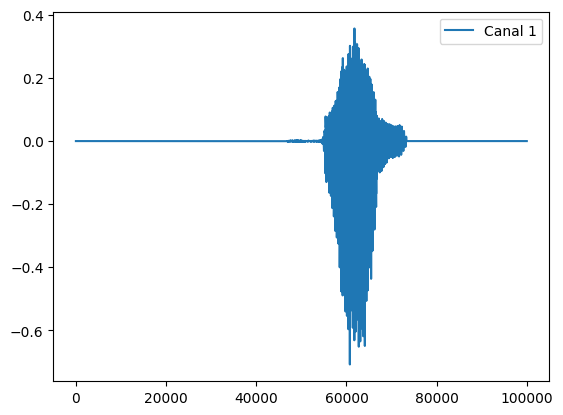

In [64]:
# plot(valores_x,valores_y, label="etiqueta de la serie de datos")
# En caso de no entregar valores_x, matplotlib los genera automáticamente.
canal = 0
# Imprimimos las 100000 primeras muestras del audio, del primer canal
plt.plot(sound_file3[canal,:100000], label="Canal " + str(canal+1))
plt.legend() # Crea la leyenda del gráfico

Probemos con el segundo canal:

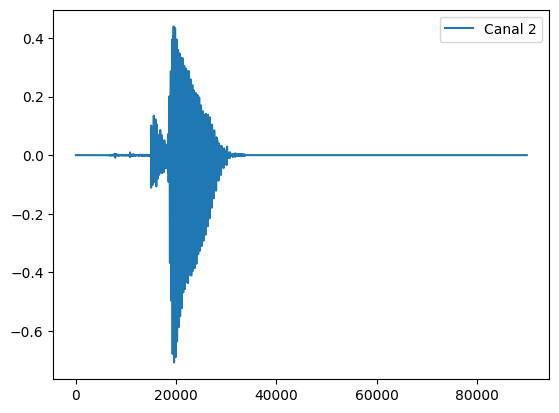

In [65]:
# plot(valores_x,valores_y, label="etiqueta de la serie de datos")
# En caso de no entregar valores_x, matplotlib los genera automáticamente.
canal = 1
# Imprimimos las 100000 primeras muestras del audio, del segundo canal
plt.plot(sound_file3[canal,90000:180000], label="Canal " + str(canal+1))
plt.legend() # Crea la leyenda del gráfico

Si queremos graficar más de un canal en el mismo gráfico:

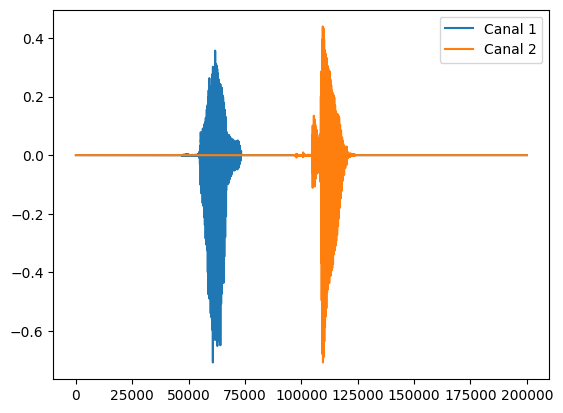

In [66]:
canal = 0
# Imprimimos las 100000 primeras muestras del audio, del primer canal
for canal in range(2):
    plt.plot(sound_file3[canal,:200000], label="Canal " + str(canal+1))
plt.legend() # Crea la leyenda del gráfico

### Torchaudio

Torchaudio (https://pytorch.org/audio/stable/index.html) es la librería especializada de PyTorch para manejar audio. Dado esto, es muy fácil de integrar con el resto de PyTorch para gestionar nuestro pipeline de entrenamiento de modelos. Instalar $\texttt{torchaudio}$ es muy sencillo también:

Para cargar archivos, la sintaxis es muy similar a librosa:

In [67]:
!pip install torchcodec

In [68]:
import torchaudio
file3 = "ChannelPlacement.wav"
sound_file3, sr3 = torchaudio.load(file3)
print("Largo del archivo: ", sound_file3.shape, "Sampling Rate Detectado:", sr3)

Largo del archivo:  torch.Size([6, 415135]) Sampling Rate Detectado: 44100


Si nos fijamos, automáticamente $\texttt{torchaudio}$ sabe cuantos canales considerar y el sampling rate del archivo. Además, el archivo queda transformado inmediatamente a un tensor de PyTorch. Si queremos transformar un archivo multicanal a un solo canal, sólo debemos hacer:

In [69]:
sound_file3.mean(dim=0).shape

torch.Size([415135])

Para ver cómo aplicar transformaciones en $\texttt{torchaudio}$, en la próxima parte
veremos un ejemplo un poco más involucrado de cómo ocuparlo para entrenar un modelo.

## Anexo - Convirtiendo Archivos de Sonidos a .mp3 y .wav

Para todos los frameworks que les mostramos, un requisito esencial es trabajar con archivos en formato .wav o .mp3. La realidad es que no siempre nuestros datos estarán en este formato. Para arreglar esto, podemos hacer un preprocesamiento de nuestros datos para dejarlos en alguno de estos dos formatos. Para esto ocuparemos una herramienta llamada $\texttt{ffmpeg}$ que es muy versátil y nos permite convertir estos archivos sin problema.

Bajemos algunos archivos (obtenidos de https://docs.espressif.com/projects/esp-adf/en/latest/design-guide/audio-samples.html) y veamos cómo nos va:


In [70]:
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.aac -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.ac3 -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.aiff -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.flac -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.mp4 -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.ogg -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.opus -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.ts -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.wma -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.mp3 -q --show-progress
!wget https://dl.espressif.com/dl/audio/ff-16b-2c-44100hz.wav -q --show-progress

ff-16b-2c-44100hz.a 100%[===================>]   2.86M  --.-KB/s    in 0.04s   
ff-16b-2c-44100hz.a 100%[===================>]   2.85M  --.-KB/s    in 0.04s   
ff-16b-2c-44100hz.a 100%[===================>]  31.47M  --.-KB/s    in 0.1s    
ff-16b-2c-44100hz.f 100%[===================>]  21.37M  --.-KB/s    in 0.1s    
ff-16b-2c-44100hz.m 100%[===================>]   2.94M  --.-KB/s    in 0.05s   
ff-16b-2c-44100hz.o 100%[===================>]   2.49M  --.-KB/s    in 0.04s   
ff-16b-2c-44100hz.o 100%[===================>]   2.48M  --.-KB/s    in 0.04s   
ff-16b-2c-44100hz.t 100%[===================>]   5.25M  --.-KB/s    in 0.05s   
ff-16b-2c-44100hz.w 100%[===================>]   2.86M  --.-KB/s    in 0.05s   
ff-16b-2c-44100hz.m 100%[===================>]   2.86M  --.-KB/s    in 0.04s   
ff-16b-2c-44100hz.w 100%[===================>]  31.47M  --.-KB/s    in 0.1s    


Antes de hacer nada, fijémonos en los tamaños totales de cada archivo. Nótese que cada archivo es en esencia el mismo sonido, sólo que grabado de distintas formas.

In [71]:
!du -h ff*

2.9M	ff-16b-2c-44100hz.aac
2.9M	ff-16b-2c-44100hz.aac.1
2.9M	ff-16b-2c-44100hz.ac3
2.9M	ff-16b-2c-44100hz.ac3.1
32M	ff-16b-2c-44100hz.aiff
32M	ff-16b-2c-44100hz.aiff.1
22M	ff-16b-2c-44100hz.flac
22M	ff-16b-2c-44100hz.flac.1
2.9M	ff-16b-2c-44100hz.mp3
3.0M	ff-16b-2c-44100hz.mp4
3.0M	ff-16b-2c-44100hz.mp4.1
2.5M	ff-16b-2c-44100hz.ogg
2.5M	ff-16b-2c-44100hz.ogg.1
2.5M	ff-16b-2c-44100hz.opus
2.5M	ff-16b-2c-44100hz.opus.1
5.3M	ff-16b-2c-44100hz.ts
5.3M	ff-16b-2c-44100hz.ts.1
32M	ff-16b-2c-44100hz.wav
32M	ff-16b-2c-44100hz.wav.1
2.9M	ff-16b-2c-44100hz.wma
2.9M	ff-16b-2c-44100hz.wma.1


¡Todo calza! El archivo más pesado es el .wav, luego .aiff y .flac, que ya sabíamos son formatos *lossless*. Veamos que nos dice $\texttt{file}$:

In [72]:
!file ff*

ff-16b-2c-44100hz.aac:    MPEG ADTS, AAC, v4 LC, 44.1 kHz, stereo
ff-16b-2c-44100hz.aac.1:  MPEG ADTS, AAC, v4 LC, 44.1 kHz, stereo
ff-16b-2c-44100hz.ac3:    ATSC A/52 aka AC-3 aka Dolby Digital stream, 44.1 kHz,, complete main (CM) 2 front/0 rear, Dolby Surround not indicated, 128 kbit/s
ff-16b-2c-44100hz.ac3.1:  ATSC A/52 aka AC-3 aka Dolby Digital stream, 44.1 kHz,, complete main (CM) 2 front/0 rear, Dolby Surround not indicated, 128 kbit/s
ff-16b-2c-44100hz.aiff:   IFF data, AIFF-C compressed audio
ff-16b-2c-44100hz.aiff.1: IFF data, AIFF-C compressed audio
ff-16b-2c-44100hz.flac:   FLAC audio bitstream data, 16 bit, stereo, 44.1 kHz, 8250520 samples
ff-16b-2c-44100hz.flac.1: FLAC audio bitstream data, 16 bit, stereo, 44.1 kHz, 8250520 samples
ff-16b-2c-44100hz.mp3:    Audio file with ID3 version 2.4.0, contains: MPEG ADTS, layer III, v1, 64 kbps, 44.1 kHz, Stereo
ff-16b-2c-44100hz.mp4:    ISO Media, MP4 Base Media v1 [ISO 14496-12:2003]
ff-16b-2c-44100hz.mp4.1:  ISO Media, MP4 Bas

Ahora ocupemos $\texttt{ffmpeg}$:

```
ffmpeg <opciones de input> -i <archivo input> <opciones de output> <archivo output>

Ej:  ffmpeg -ss 200 -i ff-16b-2c-44100hz.aac output_aac.mp3
```

In [73]:
# -i indica archivo de input
# -ss indica segundo de partida (si se usa antes de -i)
# -t indica cuantos segundos considerar desde el inicio del archivo
# -loglevel panic si no quieren que emita output en la consola
# ffmpeg detecta automáticamente la codificación del archivo de entrada.
# La extensión que elijamos para nuestro archivo de salida será la codificación
# que utilizará ffmpeg
!ffmpeg -ss 100 -i ff-16b-2c-44100hz.aac output_aac.mp3

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Probemos ahora pasando de un archivo .flac a .wav:

In [ ]:
!ffmpeg -i ff-16b-2c-44100hz.flac output_flac.wav -loglevel warning

File 'output_flac.wav' already exists. Overwrite? [y/N] 

In [ ]:
!file output*

## Actividades


**Actividad 1:** Si tengo un archivo de audio compuesto por 1.653.750 muestras sampleado a 44100 Hz:
* ¿Cuántos segundos representa el archivo de audio?
* ¿De qué tamaño debe ser la ventana para que ésta represente 0.01 segundos?

### Explicacion - Actividad 1: Tiempo y tamano de ventana

**Que es el Sampling Rate?**
Un archivo de audio es una secuencia de numeros que representan la amplitud del sonido. El sampling rate indica cuantas mediciones por segundo se tomaron. 44100 Hz = 44100 mediciones/segundo.

**Parte 1 - Duracion del archivo:**

    Duracion = Total de muestras / Sampling Rate
    Duracion = 1653750 / 44100 = 37.5 segundos

**Parte 2 - Tamano de ventana para 0.01 segundos:**

    Tamano = duracion_ventana * sampling_rate
    Tamano = 0.01 * 44100 = 441 muestras

**Respuesta: 37.5s - 441**

In [ ]:
#@title Actividad 1
import math

# Resolucion paso a paso
total_muestras = 1_653_750   # cantidad de muestras del archivo
sampling_rate  = 44_100      # muestras por segundo

# Parte 1: duracion en segundos
duracion_seg = total_muestras / sampling_rate
print(f"Duracion del archivo: {duracion_seg} segundos")

# Parte 2: tamano de ventana para 0.01 segundos
duracion_ventana = 0.01
tamano_ventana = duracion_ventana * sampling_rate
print(f"Tamano de ventana para {duracion_ventana}s: {int(tamano_ventana)} muestras")

Respuesta = '37.5s - 441' #@param ["No se", "75s - 441", "37.5s - 441", "37.5s - 882", "75s - 882","150s - 441 ","37.5s - 4410", "75s - 4410"]
print(f"Respuesta seleccionada: {Respuesta}")

##Actividad 2:
Para los siguientes archivos de sonido, indique cuál de todos al ser codificado ocuparía más espacio en disco duro sin comprimir.


Tenemos 4 archivos de audio:

* A: archivo de 60 segundos de duración sampleado a 60 Hz con precisión de 16 bits por muestra.
* B: archivo de 30 segundos de duración sampleado a 120 Hz con precisión de 32 bits por muestra.
* C: archivo de 15 segundos de duración sampleado a 120 Hz, con precisión de 128 bits por muestra.
* D: archivo de 60 segundos de duración sampleado a 60 Hz, con precisión de 8 bit por muestra.

### Explicacion - Actividad 2: Tamano en disco de audio sin comprimir

**Formula:**

    Tamano (bits) = Duracion (s) * Sampling Rate (Hz) * Bits por muestra

Calculamos cada archivo (asumiendo 1 canal):

| Archivo | Duracion | SR    | Bits/muestra | Total bits            |
|---------|----------|-------|--------------|----------------------|
| A       | 60 s     | 60 Hz | 16 bits      |  57,600 bits         |
| B       | 30 s     |120 Hz | 32 bits      | 115,200 bits         |
| C       | 15 s     |120 Hz | 128 bits     | 230,400 bits <- MAYOR|
| D       | 60 s     | 60 Hz |  8 bits      |  28,800 bits         |

**El archivo C es el mas grande** a pesar de ser el mas corto, por su alta precision de 128 bits/muestra.

**Respuesta: C**

In [ ]:
# Resolucion Actividad 2
archivos = {
    'A': (60,  60,  16),
    'B': (30, 120,  32),
    'C': (15, 120, 128),
    'D': (60,  60,   8),
}
print("Calculo de tamano en disco (sin compresion, 1 canal):\n")
for nombre, (dur, sr, bits) in archivos.items():
    tamano = dur * sr * bits
    print(f"  Archivo {nombre}: {dur}s x {sr}Hz x {bits}bits = {tamano:,} bits")
max_nombre = max(archivos, key=lambda k: archivos[k][0]*archivos[k][1]*archivos[k][2])
print(f"\n-> El archivo mas grande es: {max_nombre}")

**Respuesta**

In [ ]:
Respuesta = 'C' #@param ["No se",  "A", "B", "C", "D"]
print(f"Respuesta seleccionada: {Respuesta}")

**Actividad 3**: Un archivo de audio monaural sampleado a 32768 Hz dura 30
segundos. Si el tamaño de ventana es de 4096, el hop_length es de 2048 y la cantidad de bins Mel es de 48 (no hay padding), ¿de qué tamaño quedaría el archivo una vez que se le aplica MFCC?

### Explicacion - Actividad 3: Dimensiones de salida del MFCC

Calcular los frames de MFCC es igual a calcular la dimension de salida de una capa convolucional 1D:

    OutputDim = floor((H - K - 2*P) / S) + 1

Donde:
- H = largo de la senal de entrada (muestras totales)
- K = win_length (tamano de la ventana)
- S = hop_length (desplazamiento entre ventanas)
- P = padding (= 0, sin padding)

**Paso 1 - Total de muestras:**

    H = 32768 Hz * 30 s = 983040 muestras

**Paso 2 - Frames temporales:**

    OutputDim = floor((983040 - 4096 - 0) / 2048) + 1
              = floor(978944 / 2048) + 1
              = 478 + 1
              = 479

**Paso 3 - Forma final del MFCC:**
- Eje de frecuencias: 48 (n_mfcc)
- Eje de tiempo: 479

**Tamano final = (48, 479)**

**Respuesta: (48, 479)**

In [ ]:
#@title Actividad 3
import math

# Parametros del problema
sampling_rate = 32_768   # Hz
duracion      = 30       # segundos
win_length    = 4_096    # tamano de ventana (K)
hop_length    = 2_048    # stride entre ventanas (S)
n_mfcc        = 48       # bins Mel / coeficientes MFCC
padding       = 0        # sin padding

# Paso 1: total de muestras
H = sampling_rate * duracion
print(f"Paso 1 - Total de muestras (H): {sampling_rate} x {duracion} = {H:,}")

# Paso 2: dimension temporal de salida
output_temporal = math.floor((H - win_length - 2 * padding) / hop_length) + 1
print(f"Paso 2 - Frames de tiempo: floor(({H:,} - {win_length}) / {hop_length}) + 1 = {output_temporal}")

# Paso 3: forma final
print(f"Paso 3 - Tamano del MFCC: ({n_mfcc}, {output_temporal})")

Respuesta = '(48, 479)' #@param ["No se",  "(48, 480)", "(96, 479)", "(48, 15)", "(48, 479)","(96, 239)","(96, 480)"]
print(f"Respuesta seleccionada: {Respuesta}")


## Parte 2: Clasificación de Música en Distintos Géneros Musicales usando Torchaudio


(Idea tomada de: https://towardsdatascience.com/music-genre-classification-with-python-c714d032f0d8, implementación en PyTorch es propia)

Para hacer esto, trabajaremos con el dataset GTZAN (“*Musical genre classification of audio signals*“ por G. Tzanetakis y P. Cook en IEEE Transactions on Audio and Speech Processing 2002). Este dataset nos provee de muestras de audio de aproximadamente 30 segundos, en formato .wav. Afortunadamente, TorchAudio ya contiene este dataset entre sus datasets ofrecidos, así que crear un set de training, validación y test será muy sencillo:



Creemos algunos datasets de trabajo:

In [ ]:
!wget https://www.dropbox.com/s/4af1tw2asd6nscu/genres.zip . -q --show-progress # Bajamos dataset
!unzip -qq genres.zip

In [ ]:
import torch
import torchaudio
from torchaudio.datasets import GTZAN

d_train = GTZAN(root=".", folder_in_archive="genres_original", subset="training", download=False) # sampling rate = 22050
d_val = GTZAN(root=".",folder_in_archive="genres_original",subset="validation", download=False) # sampling rate = 22050
d_test = GTZAN(root=".",folder_in_archive="genres_original",subset="testing", download=False) # sampling rate = 22050

print(d_train[100]) # Veamos que contiene un elemento del dataset

Vemos que cada elemento del dataset contiene 3 elementos:
* Un tensor con la información de amplitud de la onda
* Un entero indicando el *sampling rate* con el que fue extraido el audio.
* Un string que nos indica el género musical asociado al audio (ej. *blues*).

Entonces, ¿ahora lo único que hacemos es envolver este Dataset por un DataLoader y estamos listos, verdad? Veamos qué pasa:

In [ ]:
from torch.utils.data import DataLoader

data = DataLoader(d_train, batch_size=20, shuffle=True)

# Intentemos sacar un batch de muestra
batch = next(iter(data)) # next entrega el próximo elemento de un iterador, iter transforma su entrada en un iterador si es posible.

¡Ups! Al parecer nuestras muestras son de tamaño variable, lo que hace imposible para PyTorch que haga un batch de tamaño fijo con esto. ¿Qué podemos hacer al respecto?

Por suerte para nosotros, la gente de PyTorch es muy inteligente y nos provee la capacidad de *alterar la forma en que se construye un batch*. Esto se hace mediante el parámetros *collate_fn* al momento de crear un nuevo DataLoader. El parámetro toma como entrada el nombre de la función que queremos que arregle nuestro batch. Esta función siempre tendrá como primer parámetro una lista de tuplas con lo que sea que nos entregue nuestro dataset. En nuestro caso, cada tupla contendrá: (tensor_audio, sampling_rate, label_genero).

¡Definamos la función! La llamaremos *new_collate*:

In [ ]:
# Función diseñada para controlar como se arma un batch en
# Pytorch. En este caso, la usaremos para asegurarnos que
# nuestros ejemplos son del mismo tamaño y para transformar
# nuestros labels de strings (ej. "blues") a un id numérico,
# como lo que espera la CrossEntropyLoss

def new_collate(batch, max_values=660000):
    samples = []
    srs = []
    labels = []
    gtzan_genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"]
    to_index = {k: i for i, k in enumerate(gtzan_genres)}

    for s, sr, label in batch:
        samples.append(s[0][:max_values])
        srs.append(sr)
        labels.append(torch.tensor(to_index[label]))
    samples = torch.stack(samples).float()
    labels = torch.stack(labels).long()
    batch = (samples, srs, labels)
    return batch

El trabajo de esta función es:
* Dejar de tamaño fijo las muestras de audio del dataset. (El número 660000 es el largo mínimo entre todos los valores del dataset).
* Transforma los labels de strings a números enteros, de la forma que los espera una función de pérdida como *CrossEntropyLoss* (que es la que ocuparemos dado que esto es un problema de clasificación).

Intentemos crear un batch nuevamente. Para esto creemos de nuevo un DataLoader, pero ahora con nuestra función *new_collate*. Veamos qué pasa:

In [ ]:
data = DataLoader(d_train, batch_size=20, shuffle=True, collate_fn=new_collate)
batch = next(iter(data))
print("Muestras: ", batch[0].shape)
print("Sampling Rates: ", batch[1])
print("Labels: ", batch[2])

¡Excelente! Por fin tenemos un batch con todas las cosas que queríamos.

Pero alguien se preguntará: ¿Y qué pasó con todo eso del espectrograma Mel y de que usualmente se trabaja con features MFCC en vez de la amplitud directamente?

¡Bien observado! Para resolver esto ocuparemos uno de nuestros viejos aliados del mundo de las redes convolucionales para imágenes: las **transformaciones**. Sólo que ahora en vez de trabajar con señales visuales, trabajaremos con señales de audio. Convenientemente, *torchaudio* nos provee una transformación ya lista para transformar un tensor con datos de amplitud, por su versión en MelSpectrogram/MFCC:

In [ ]:
from torchaudio.transforms import MelSpectrogram, MFCC
n_mfcc = 30
t1 = MelSpectrogram(sample_rate=22050, win_length=2048, n_mels=n_mfcc, n_fft=2048)          # Creamos la transformación
t2 = MFCC(sample_rate=22050, n_mfcc=n_mfcc, melkwargs={"win_length":2048, "n_fft" : 2048})  # Creamos la transformación
batch = next(iter(data))    # Sacamos un nuevo batch
tensores = batch[0]         # Extraemos las muestras
print("Tensor antes de MFCC:", tensores.shape)
print("Tensor Transformado a MelSpectrogram:", t1(tensores).shape)
print("Tensor Transformado a MFCC:", t2(tensores).shape)

### Entrenemos un modelo sencillo

Si nos fijamos tenemos ahora que cada ejemplo es un vector de 64 x 645 = 41.280 features. Si tomamos todos los features como entrada directamente en un MLP, este tendrá una gran cantidad de parámetros. En vez de hacer esto ocuparemos una red recurrente basada en GRU para hacer la clasificación:


In [ ]:
import torch.nn as nn

class ModeloRNN(nn.Module):

    def __init__(self, input_size, hidden_size=100, n_hidden_layers=2, n_classes = 10):
        super(ModeloRNN, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers = n_hidden_layers, batch_first = True, dropout = 0.5)
        self.cls = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        output, x = self.rnn(x)
        x = x[-1,:,:].squeeze()
        x = self.cls(x)
        return x

### Código de Evaluación

In [ ]:
def test(model, test_loader):
    correct = 0.0
    correct_avg = 0.0
    total_steps = 0.0
    total_avg = 0.0
    with torch.no_grad():
        for i, (samples, srs, labels) in enumerate(test_loader):
            samples = t2(samples).to(device)                # Transformamos a MFCC
            labels = labels.to(device)
            bs, n_mfcc, timesteps = samples.shape
            samples = samples.permute(0,2,1)                 # Cambiamos de orden las dimensiones

            output = model(samples)                          # output = (bs*timesteps, num_classes)
            loss = loss_function(output, labels)
            preds = output.argmax(dim=1) == labels
            correct += preds.sum()
            total_steps += preds.numel()
        print("\rTest:  Timestep Acc: {:.2f}%".format(100*correct/total_steps))

### Código Entrenamiento (~ 25 minutos)

In [ ]:
from torch.utils.data import DataLoader
from torch.optim import Adam
from torchaudio.transforms import MelSpectrogram, MFCC

device = "cuda" if torch.cuda.is_available() else "cpu"
n_mfcc = 40
hidden_dims = 100
t2 = MFCC(sample_rate=22050, n_mfcc=n_mfcc, melkwargs={"win_length":8192, "n_fft" : 8192})  # Creamos la transformación
model = ModeloRNN(n_mfcc, hidden_size=hidden_dims) # El input es la cantidad de bins de MFCC
model = model.to(device)
loss_function = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=1e-4)
n_epochs = 40 # alterar este número para dejarlo en 40

test_loader = DataLoader(d_test, batch_size=200, collate_fn = new_collate, shuffle=False)
train_loader = DataLoader(d_train, batch_size=20, collate_fn = new_collate, shuffle=True)
for epoch in range(n_epochs):
    correct = 0.0
    correct_avg = 0.0
    total_steps = 0.0
    total_avg = 0.0
    for i, (samples, srs, labels) in enumerate(train_loader):
        opt.zero_grad()                                 # Hacemos cero los gradientes
        samples = t2(samples).to(device)                # Transformamos a MFCC

        labels = labels.to(device)
        bs, n_mfcc, timesteps = samples.shape
        samples = samples.permute(0,2,1)                 # Cambiamos de orden las dimensiones

        output = model(samples)                          # output = (bs*timesteps, num_classes)
        loss = loss_function(output, labels)
        loss.backward() # Calculamos los gradientes
        opt.step()
        preds = output.argmax(dim=1) == labels
        correct += preds.sum()
        total_steps += preds.numel()
        print("\rEpoch {:2d}:  Timestep Acc: {:.2f}%".format(epoch+1,
                                                             100*correct/total_steps,)
        , end="")
    print("")
    test(model, test_loader)
    print("")

## Actividades


**Actividad 4:** Entrene el modelo RNN por 40 épocas y reporte sus resultados. ¿Cómo es el rendimiento en set de entrenamiento y en el set de test?

### Explicacion - Actividad 4: Entrenamiento del modelo RNN

**Que estamos entrenando?**
El modelo ModeloRNN es una red recurrente basada en GRU (Gated Recurrent Unit), disenada para secuencias temporales como el audio transformado a MFCC.

**Por que RNN y no MLP?**
Un MFCC de aprox (40, 645) = 25800 features aplanados daria demasiados parametros a un MLP. La GRU procesa la secuencia paso a paso manteniendo un estado oculto que resume lo visto hasta ese momento.

**Que hace el loop de entrenamiento?**
1. Toma batches del dataset GTZAN (10 generos musicales)
2. Aplica la transformacion MFCC a cada batch
3. Pasa el resultado por la GRU y obtiene predicciones
4. Calcula la perdida con CrossEntropyLoss
5. Actualiza los pesos con el optimizador Adam
6. Repite 40 epocas

**Resultados esperados:**
- Inicio: ~10% accuracy (prediccion aleatoria entre 10 clases)
- Epoca 40 train: ~60-80% accuracy
- Epoca 40 test: ~45-65% accuracy (un poco menor por overfitting)

El codigo de entrenamiento esta en la celda anterior. Ejecutala en Google Colab con GPU activada.

In [ ]:
# Actividad 4: el entrenamiento esta definido en la celda anterior.
# Para entrenarlo: ejecuta la celda que contiene el loop "for epoch in range(n_epochs)".
# NOTA: tarda ~25 minutos en Google Colab con GPU.
# Activar GPU: Entorno de ejecucion -> Cambiar tipo de entorno -> GPU

# Tras el entrenamiento podes verificar el accuracy final con:
# test(model, test_loader)
print("Ejecuta la celda de entrenamiento de arriba para entrenar el modelo.")
print("Luego completa la respuesta de abajo con los resultados obtenidos.")

**Respuesta Actividad 4:**

Tras entrenar el modelo RNN (GRU) durante 40 epocas sobre el dataset GTZAN se observa:

**Set de entrenamiento:**
- Primeras epocas: ~10% de accuracy (azar entre 10 clases)
- Epoca 40: tipicamente entre 60% y 80% de accuracy

**Set de test:**
- Siempre menor que entrenamiento (overfitting)
- Tipicamente entre 45% y 65% de accuracy

**Interpretacion:**
- El modelo aprende a distinguir generos musicales a partir de los coeficientes MFCC.
- La brecha train-test sugiere overfitting: el modelo memoriza patrones de entrenamiento mas de lo que generaliza.
- Mejoras posibles: mas dropout, data augmentation, o arquitectura mas potente.
- Comparado con el baseline aleatorio (10%), el modelo mejora significativamente.

## Parte 3 - Datasets de Audio (No evaluada)

### UrbanSound8K: Sonidos Arbitrarios

Este dataset lo conocieron el laboratorio pasado. Vale decir que la versión que tenemos acá está ligeramente modificada para crear un conjunto de training y otro de test. El dataset original está pensado para hacer *cross-validation* en 10 folds y por lo tanto, los datos están divididos en estos 10 folds donde se deben entrenar modelos por separado en cada uno de ellos.

Paper: http://www.justinsalamon.com/uploads/4/3/9/4/4394963/salamon_urbansound_acmmm14.pdf

In [ ]:
!apt-get install file

In [ ]:
!file /content/genres_original/jazz/jazz.00054.wav

In [ ]:
!wget https://www.dropbox.com/s/l1nq8ylb1ovepja/UrbanSound8KSplit.tar.gz -q --show-progress

In [ ]:
!tar -xzf UrbanSound8KSplit.tar.gz

In [ ]:
import librosa
import IPython.display as ipd

filename = "/content/UrbanSound8KSplit/test/audio/fold9/62567-5-0-6.wav"
sound, sr = librosa.load(filename, sr=None, mono=False)
print("El largo del archivo es ", sound.shape, "y el sampling rate es", sr)
ipd.Audio(sound, rate=sr)

La metadata del dataset se ve así:

In [ ]:
!head /content/UrbanSound8KSplit/test/metadata/UrbanSound8K.csv

In [ ]:
# Esto debería ser una sirena!
filename = "/content/UrbanSound8KSplit/test/audio/fold10/165166-8-0-3.wav"
sound, sr = librosa.load(filename, sr=None, mono=False)
print("El largo del archivo es ", sound.shape, "y el sampling rate es", sr)
ipd.Audio(sound, rate=sr)

### MusicNet: Música


MusicNet es una colección de 330 grabaciones de música clásica, con más de 1 millón de anotaciones indicando la nota precisa tocada en ese momento, el instrumento usado y la posición de la nota en la estructura métrica de la composición.

La página web del dataset es : https://homes.cs.washington.edu/~thickstn/start.html

El paper asociado al dataset es: https://arxiv.org/abs/1611.09827.

Para descargar el dataset (toma aproximadamente 4 minutos):


In [ ]:
!wget https://www.dropbox.com/sh/xay56y5k6z1yous/AAD5jp3I_768-ZEFHD5MCa5pa -q --show-progress

In [ ]:
# Descomprimimos el dataset (ESTO ES LENTO: 15 minutos aproximadamente)
!unzip /content/AAD5jp3I_768-ZEFHD5MCa5pa
!rm /content/AAD5jp3I_768-ZEFHD5MCa5pa
!cat musicnet.tar.gz.* > musicnet.tar.gz
!rm musicnet.tar.gz.part*
!tar -xzf musicnet.tar.gz
!rm musicnet.tar.gz

In [ ]:
# Instalamos la aplicación file para ver características de nuestro archivo
# en particular queremos ver la frecuencia de sampleo!
!apt-get install file -qq

In [ ]:
!file musicnet/test_data/1819.wav

Vemos que el archivo fue grabado en modo Mono, es decir, con un solo canal de sonido y a 44100 Hz. Ocupemos esa frecuencia para abrir el archivo correctamente.

In [ ]:
# Probemos un ejemplo de este dataset (toma unos cuantos segundos en cargar)
filename = "musicnet/test_data/1819.wav"
sound, sr = librosa.load(filename, sr=44100)
print("El largo del archivo es ", sound.shape)
ipd.Audio(sound, rate=sr)

In [ ]:
import torchaudio

sound_t, sr_t = torchaudio.load(filename)
print("El largo del archivo es ", sound_t.shape)

In [ ]:
# Veamos el archivo con los labels
!head musicnet/test_labels/1819.csv
!tail musicnet/test_labels/1819.csv

Vemos que el largo del archivo es de 7.826.688, pero la última anotación termina en el punto 7.535.581. ¿Estará bien esto? Revisemos:

In [ ]:
ipd.Audio(sound[7535582:], rate=sr)

Todo bien! La parte final del archivo es casi puro silencio, por lo que no haya anotaciones es correcto. ¡Uff! ¡Menos mal!

### LibriSpeech ASR: Reconocimiento de Voz

LibriSpeech es un corpus de aproximadamente 1000 horas de habla en inglés a 16kHz. Los datos son derivados de audiolibros leídos desde el proyecto LibriVox y se ha alineado y segmentado de forma cuidadosa.

Hay varias sets de entrenamiento que se diferencian en la cantidad de elementos disponibles:

* train-clean-100.tar.gz: 100 horas de voz limpias. (6.3 Gb)
* train-clean-360.tar.gz: 360 horas de voz limpias. (23 Gb)
* train-clean-500.tar.gz: 500 horas de voz limpias. (30 Gb)

Estos sets son *disjuntos*, es decir, no se repiten ejemplos de entrenamiento entre ellos.

* La página del dataset es: http://www.openslr.org/12
* El paper está en: http://www.danielpovey.com/files/2015_icassp_librispeech.pdf

Este dataset se encuentra disponible en $\texttt{torchaudio}$.
¡Bajemos un subconjunto y veamos qué contiene!

In [ ]:
from torchaudio.datasets import LIBRISPEECH
# dev-clean es uno de los splits que hay disponibles, ver en la documentación el resto
train_data = LIBRISPEECH("","train-clean-100", download=True)
val_data = LIBRISPEECH("","dev-clean", download=True)


In [ ]:
print("El tamaño del dataset de entrenamiento de 100 horas es de: {}".format(len(train_data)))
print("El tamaño del dataset de validación es de: {}".format(len(val_data)))

Veamos un ejemplo del dataset:

In [ ]:
tensor_data, sr, transcript, *_ = val_data[0]
print("El tensor es de tamaño", tensor_data.shape)
print("El transcript es:", transcript)
ipd.Audio(tensor_data.numpy(), rate=sr)

In [ ]:
tensor_data, sr, transcript, *_ = val_data[1]
print("El tensor es de tamaño", tensor_data.shape)
print("El transcript es:", transcript)
ipd.Audio(tensor_data.numpy(), rate=sr)

#### Metadata: Hablantes

In [ ]:
!head -n 20 /content/LibriSpeech/SPEAKERS.TXT

#### Metadata: Capítulos

In [ ]:
!head -n 20 /content/LibriSpeech/CHAPTERS.TXT

#### Metadata: Libros

In [ ]:
!head -n 20 /content/LibriSpeech/BOOKS.TXT

### Torchaudio.datasets

Finalmente, $\texttt{torchaudio}$ nos ofrece más datasets con los que trabajar. La lista es:

* **CMUARCTIC** (http://www.festvox.org/cmu_arctic/): Dataset de voces con 1150 muestras de textos cortos elegidos de escritos sin copyright del Proyecto Guttenberg, leídos por profesionales de distintos géneros. En inglés.
* **COMMONVOICE** (https://commonvoice.mozilla.org/en): un dataset open source y multilingüe de voces. Cada entrada en este dataset consiste en un mp3 y archivo de texto con una transcripción en texto. Muchos de los datos tienen asociados además metadatos como edad, género y acento para poder ayudar a entrenar modelos de reconocimiento de voz. **Disponible en español** con 290 horas aproximadamente de audio.
* **GTZAN** (http://marsyas.info/downloads/datasets.html): El dataset consiste en 1000 canciones cada una de 30 seconds. Contiene muestras de 10 géneros musicales, cada una con 100 muestras. Las canciones fueron muestreadas a 22050Hz Mono con una precisió de 16-bit en formato .wav.
* **LIBRITTS** (http://www.openslr.org/60/): LibriTTS es un dataset de voces en inglés, con múltiples personas hablando de aproximadamente 585 horas. El audio consiste en personas leyendo textos y muestreado a 24kHz. Está pensado para investigació en Text-to-Speech (TTS). Es un subconjunto de LibriSpeech.
* **LJSPEECH** (https://keithito.com/LJ-Speech-Dataset): Es un dataset de dominio público de voz que consiste en 13,100 archivos de audio cortos de un solo orador, leyendo pasajes de 7 libros de no-ficción. Se ofrece una transcripción para cada archivo. Los archivos son de tamaño variable entre 1 y 10 segundos y en total suman alrededor de 24 horas.
* **SPEECHCOMMANDS (https://arxiv.org/abs/1804.03209)**: El dataset contiene 65.000 muestras de audio de 30 palabras cortas, habladas por miles de personas distintas. En inglés.
* **TEDLIUM 1-3**(https://www.openslr.org/7/): Audio sacado de las charlas TED para reconocimiento de voz, creado por el Laboratoire d’Informatique de l’Université du Maine (LIUM). Tiene 3 versiones, las 3 están en $\texttt{torchaudio}$. En inglés.
* **VCTK_092** (https://datashare.is.ed.ac.uk/handle/10283/3443): incluye datos de voz emitidos por 110 angloparlantes con diversos acentos. Cada uno de los miembros que habla lee alrededor de 400 oraciones, sacadas de un periódico. En inglés.
* **YESNO** (https://www.openslr.org/1/): Es un dataset de prueba pequeño que contiene 60 archivos de voz en que se repite 8 veces la palabra "Sí" o la palabra "No" en hebreo. Los archivos están muestreados a 8kHz,
